This notebook will use average air temperature to calculate missing water temperature values in the Big Sioux water quality study. In the original water study, dropping rows with missing pH values also dropped all of the missing temperature values. This notebook will use the original dataframe without dropping pH values.

In [3]:
!pip install pandas
!pip install numpy
!pip install folium

# Import required libraries
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import folium
import seaborn as sns

print('done')

done


### Data set from data.gov attribution: cityofsiouxfallsgis (https://catalog.data.gov/dataset/surface-water-quality-monitoring-data)


In [5]:
df=pd.read_csv("https://dataworks.siouxfalls.gov/api/download/v1/items/effb33edd91e46ab93b9c94c9ebc82aa/csv?layers=39")

### Data Cleaning

In [7]:
# Rename the "Ph" column to "pH" (Typo in original dataset)
df.rename(columns={"Ph": "pH"}, inplace=True)

#Drop columns that are mostly empty or have entries unrelated to pH fluctuations
df.drop(["OBJECTID", "Weather", "FrozenOver", "Comments", "R_Humidity", "WindSpeed", "WindGust", "LocationID", "GlobalID"], axis=1, inplace=True)

#Remove duplicate entries in df
df = df.drop_duplicates().reset_index(drop=True)

# Replace pH values greater than 14 with 14
df.loc[df['pH'] > 14, 'pH'] = 14

# Parse the "SampleDate" column into datetime format
df['SampleDate'] = pd.to_datetime(df['SampleDate'])

# Sort the dataframe by 'SampleDate' in ascending order
df = df.sort_values(by=['Location', 'SampleDate'], ascending=[True, True])

# Check for missing values in each column
missing_values = df.isna().sum()

# Display the missing values
print("Missing values in each column:")
print(missing_values)


Missing values in each column:
SampleDate                   0
Location                     0
pH                         294
Temperature                313
DissolvedOxygen            316
Conductivity              1494
BiologicalOxygenDemand     548
TotalSuspendedSolids       319
EColi                     1650
Ammonia                    636
Nitrate                    314
dtype: int64


In [11]:
#Merge air temperature data with Big Sioux water quality data
import pandas as pd
air_temp_df = pd.read_csv("air_temperature_data.csv")

# Convert 'datetime' to datetime64
air_temp_df['datetime'] = pd.to_datetime(air_temp_df['datetime'])

df.info()
print("")
air_temp_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4046 entries, 486 to 4042
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   SampleDate              4046 non-null   datetime64[ns, UTC]
 1   Location                4046 non-null   object             
 2   pH                      3752 non-null   float64            
 3   Temperature             3733 non-null   float64            
 4   DissolvedOxygen         3730 non-null   float64            
 5   Conductivity            2552 non-null   float64            
 6   BiologicalOxygenDemand  3498 non-null   float64            
 7   TotalSuspendedSolids    3727 non-null   float64            
 8   EColi                   2396 non-null   float64            
 9   Ammonia                 3410 non-null   float64            
 10  Nitrate                 3732 non-null   float64            
dtypes: datetime64[ns, UTC](1), float64(9), object(

In [15]:
# Ensure 'datetime' in both DataFrames is in datetime format
df['SampleDate'] = pd.to_datetime(df['SampleDate'])
air_temp_df['datetime'] = pd.to_datetime(air_temp_df['datetime'])

# Extract just the date part from the datetime column
df['date'] = df['SampleDate'].dt.date
air_temp_df['date'] = air_temp_df['datetime'].dt.date

# Merge the DataFrames on 'date'
merged_df = pd.merge(
    df[['SampleDate', 'pH', 'Location', 'Temperature', 'DissolvedOxygen', 'Conductivity','BiologicalOxygenDemand', 'TotalSuspendedSolids', 'EColi', 'Ammonia', 'Nitrate','date']],  # Select relevant columns from df
    air_temp_df[['date', 'temp']],                                # Select date and air_temp columns
    on='date',                                                   # Join on the date column
    how='inner'                                                  # Keep only matching dates
)

# Rename the air temperature column
merged_df = merged_df.rename(columns={'temp': 'air_temp'})

# Drop the auxiliary 'date' column if not needed
merged_df = merged_df.drop(columns=['date'])

# Ensure 'SampleDate' has only date information
merged_df['SampleDate'] = merged_df['SampleDate'].dt.date

# View the resulting DataFrame
print(merged_df)

      SampleDate    pH                   Location  Temperature  \
0     2012-06-05  8.47  Big Sioux River @ Bahnson        24.10   
1     2012-06-08  8.50  Big Sioux River @ Bahnson        22.45   
2     2012-06-11  8.38  Big Sioux River @ Bahnson        20.50   
3     2012-06-14  7.61  Big Sioux River @ Bahnson        23.10   
4     2012-06-19  8.69  Big Sioux River @ Bahnson        26.66   
...          ...   ...                        ...          ...   
3802  2023-11-30   NaN  Skunk Creek @ Marion Road          NaN   
3803  2023-12-06  8.08  Skunk Creek @ Marion Road         0.90   
3804  2023-12-14  8.11  Skunk Creek @ Marion Road         0.30   
3805  2023-12-19  8.03  Skunk Creek @ Marion Road         0.10   
3806  2023-12-28  8.15  Skunk Creek @ Marion Road         1.00   

      DissolvedOxygen  Conductivity  BiologicalOxygenDemand  \
0                8.00         0.003                    5.30   
1                7.22         0.000                    4.40   
2                7

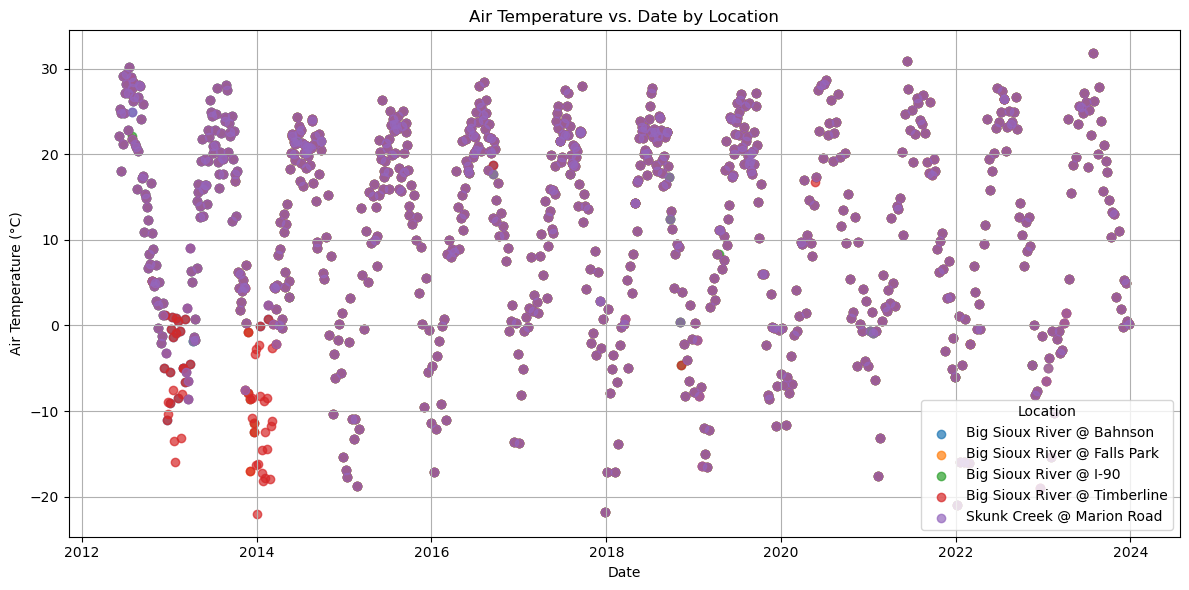

In [17]:
import matplotlib.pyplot as plt

# Create a scatter plot for each location with a unique color
plt.figure(figsize=(12, 6))
for location, data in merged_df.groupby('Location'):
    plt.scatter(
        data['SampleDate'], 
        data['air_temp'],
        label=location, 
        alpha=0.7
    )

# Add labels, title, and legend
plt.xlabel('Date')
plt.ylabel('Air Temperature (°C)')
plt.title('Air Temperature vs. Date by Location')
plt.legend(title='Location', loc='lower right')  # Move legend to bottom-right corner
plt.grid(True)
plt.tight_layout()

# Show the plot
plt.show()

Look at relationship between air temperature and water temperature

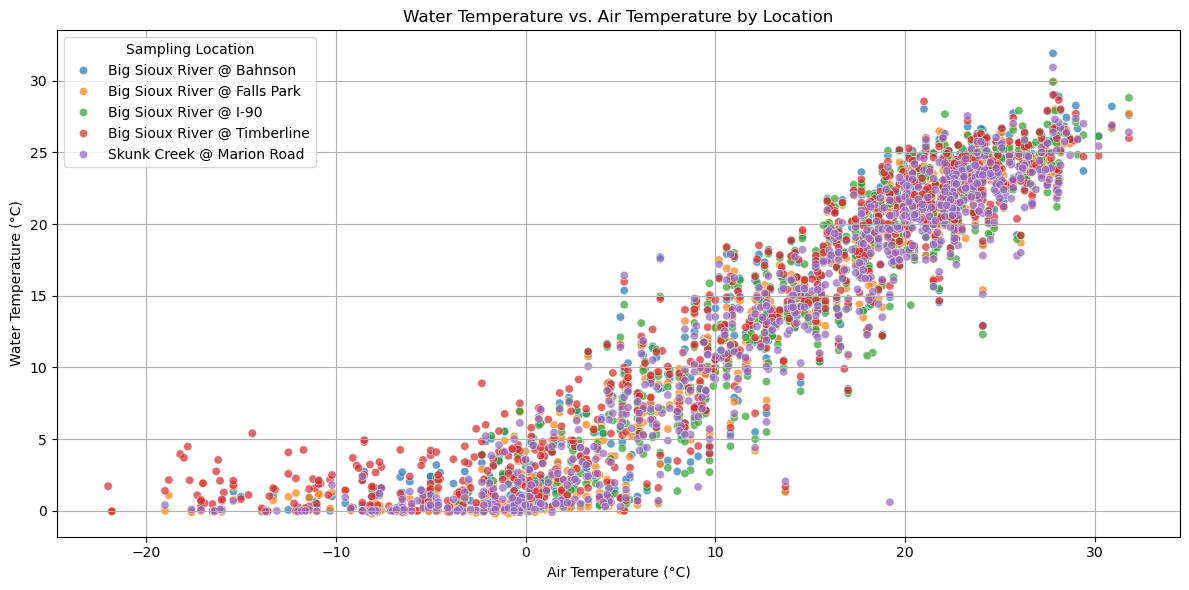

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out rows where 'Temperature' or 'air_temp' is missing
filtered_df = merged_df.dropna(subset=['Temperature', 'air_temp'])

# Create the scatter plot using seaborn
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=filtered_df,
    x='air_temp',
    y='Temperature',
    hue='Location',  # Different colors for each location
    palette='tab10', # Customize color palette (optional)
    alpha=0.7        # Adjust transparency
)

# Add labels and title
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Water Temperature (°C)')
plt.title('Water Temperature vs. Air Temperature by Location')

# Add a grid for better readability
plt.grid(True)

# Show the legend
plt.legend(title='Sampling Location', loc='best')

# Display the plot
plt.tight_layout()
plt.show()


#### The data seems to have a sigmoidal distribution which makes sense with respect to Newtonian laws of heat transfer. Decided to fit the data with air temperatures greater than 0C. Linear, saturation model and a logistic model were used to fit the data, and statistical information was collected. Additionally, each sampling location was fit separately to see if that feature had an effect.

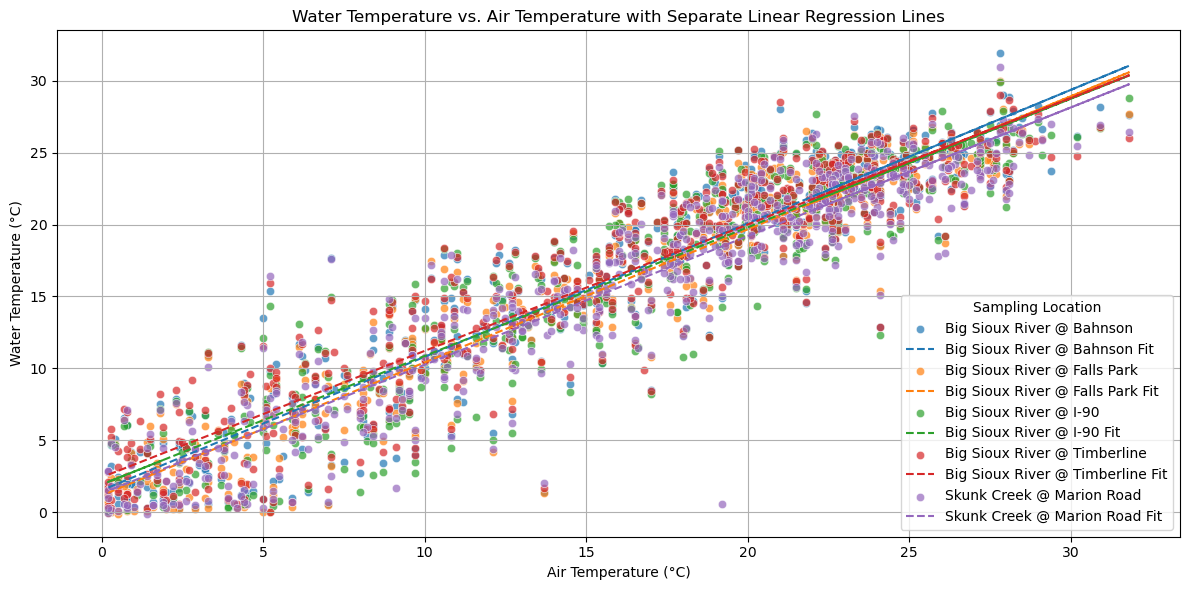

Location: Big Sioux River @ Bahnson
Equation: y = 0.93x + 1.53
R-squared: 0.8755

Location: Big Sioux River @ Falls Park
Equation: y = 0.92x + 1.17
R-squared: 0.8994

Location: Big Sioux River @ I-90
Equation: y = 0.89x + 1.93
R-squared: 0.8432

Location: Big Sioux River @ Timberline
Equation: y = 0.88x + 2.43
R-squared: 0.8652

Location: Skunk Creek @ Marion Road
Equation: y = 0.89x + 1.31
R-squared: 0.8783



In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

# Filter data for air temperatures above 0
filtered_df = merged_df.dropna(subset=['Temperature', 'air_temp'])
filtered_df = filtered_df[filtered_df['air_temp'] > 0]

# Set up the plot
plt.figure(figsize=(12, 6))

# Get unique locations and color palette
locations = filtered_df['Location'].unique()
palette = sns.color_palette('tab10', len(locations))

# Dictionary to store results
linear_results = {}

# Iterate through each location
for location, color in zip(locations, palette):
    # Subset the data for the current location
    loc_data = filtered_df[filtered_df['Location'] == location]
    
    # Prepare data for regression
    X = loc_data['air_temp'].values.reshape(-1, 1)  # Predictor variable
    y = loc_data['Temperature'].values             # Target variable
    
    # Perform linear regression
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    
    # Calculate R-squared value
    r_squared = model.score(X, y)
    
    # Store the slope and intercept
    slope = model.coef_[0]
    intercept = model.intercept_
    
    # Store results in dictionary with equation as a string
    linear_results[location] = {
        "slope": slope,
        "intercept": intercept,
        "r_squared": r_squared,
        "equation": f"y = {slope:.2f}x + {intercept:.2f}"
    }
    
    # Plot the scatter points for the current location
    sns.scatterplot(
        x=loc_data['air_temp'],
        y=loc_data['Temperature'],
        label=location,
        color=color,
        alpha=0.7
    )
    
    # Plot the regression line for the current location
    plt.plot(loc_data['air_temp'], y_pred, color=color, linestyle='--', 
             label=f"{location} Fit")

# Add labels and title
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Water Temperature (°C)')
plt.title('Water Temperature vs. Air Temperature with Separate Linear Regression Lines')

# Add a legend
plt.legend(title='Sampling Location')
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()

# Print the R-squared values and equations for each location
for location, values in linear_results.items():
    r_squared = values["r_squared"]
    equation = values["equation"]
    print(f"Location: {location}")
    print(f"Equation: {equation}")
    print(f"R-squared: {r_squared:.4f}\n")



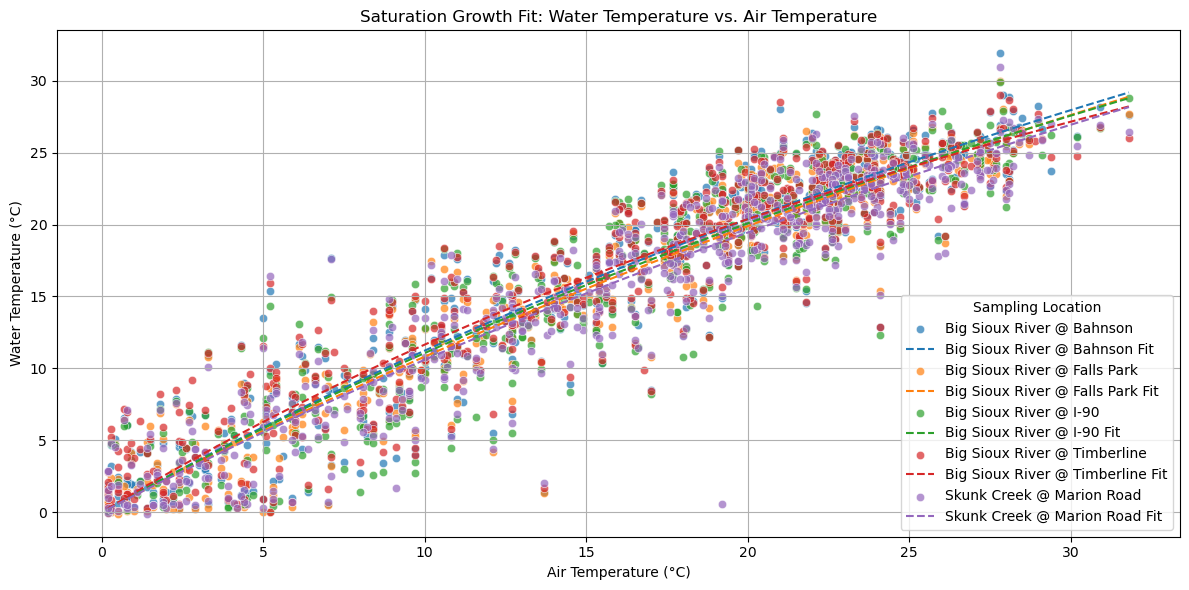

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import seaborn as sns
from sklearn.metrics import r2_score

# Saturation growth model
def saturation_model(x, a, b):
    return (a * x) / (b + x)

# Filter data for air temperatures above 0
filtered_df = merged_df.dropna(subset=['Temperature', 'air_temp'])
filtered_df = filtered_df[filtered_df['air_temp'] > 0]

# Set up the plot
plt.figure(figsize=(12, 6))

# Get unique locations and color palette
locations = filtered_df['Location'].unique()
palette = sns.color_palette('tab10', len(locations))

# Dictionary to store results
saturation_results = {}

# Fit the saturation model to each location
for location, color in zip(locations, palette):
    loc_data = filtered_df[filtered_df['Location'] == location]
    x_data = loc_data['air_temp']
    y_data = loc_data['Temperature']
    
    # Initial guesses for parameters
    p0 = [max(y_data), np.median(x_data)]
    
    try:
        # Fit the saturation model
        popt, _ = curve_fit(saturation_model, x_data, y_data, p0=p0)
        a, b = popt

        # Generate predictions
        x_fit = np.linspace(min(x_data), max(x_data), 100)
        y_fit = saturation_model(x_fit, a, b)
        
        # Calculate R-squared
        y_pred = saturation_model(x_data, *popt)
        r_squared = r2_score(y_data, y_pred)
        
        # Store results in dictionary with equation as a string
        saturation_results[location] = {
            "a": a,
            "b": b,
            "r_squared": r_squared,
            "equation": f"y = ({a:.2f} * x) / ({b:.2f} + x)"
        }
        
        # Scatter plot of data
        sns.scatterplot(x=x_data, y=y_data, label=location, color=color, alpha=0.7)
        
        # Plot the saturation growth curve
        plt.plot(x_fit, y_fit, color=color, linestyle='--', label=f"{location} Fit")
        
    except RuntimeError:
        print(f"Could not fit saturation model for {location}.")
        
# Add labels and title
plt.xlabel('Air Temperature (°C)')
plt.ylabel('Water Temperature (°C)')
plt.title('Saturation Growth Fit: Water Temperature vs. Air Temperature')
plt.legend(title='Sampling Location')
plt.grid(True)

# Display the plot
plt.tight_layout()
plt.show()



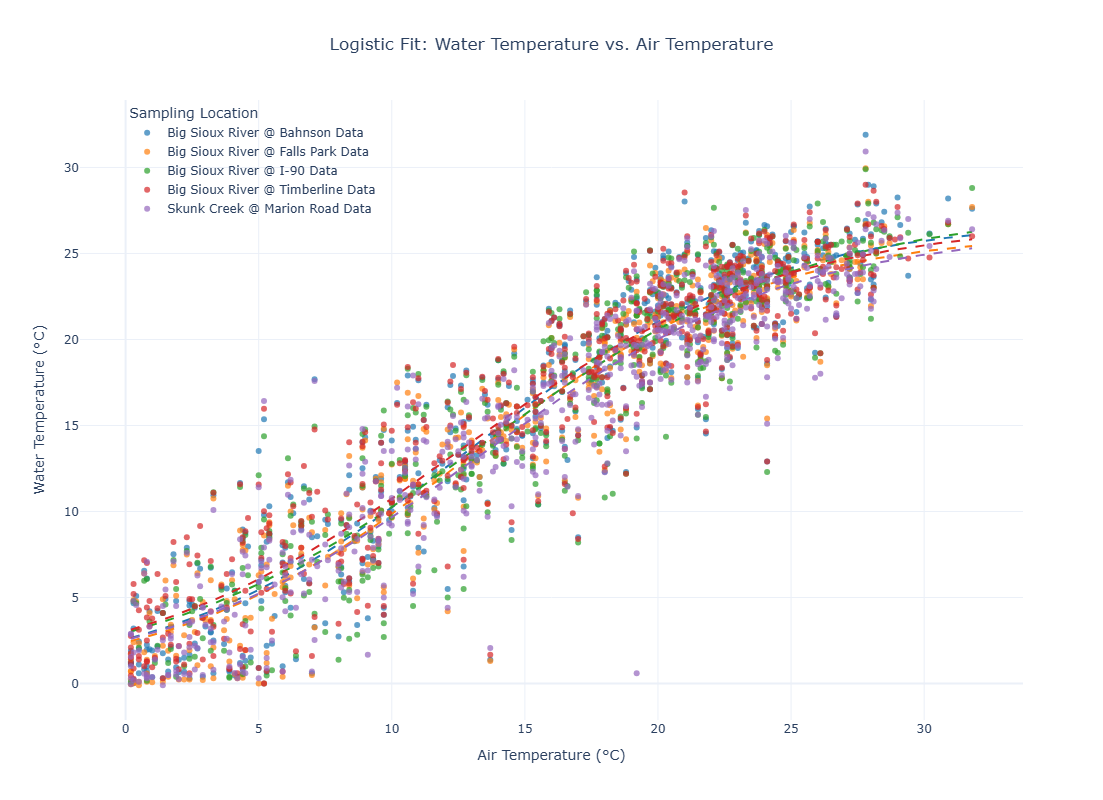

In [30]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import seaborn as sns

# Logistic function model
def logistic_model(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Filter data for air temperatures above 0
filtered_df = merged_df.dropna(subset=['Temperature', 'air_temp'])
filtered_df = filtered_df[filtered_df['air_temp'] > 0]

# Get unique locations and color palette
locations = filtered_df['Location'].unique()
palette = sns.color_palette('tab10', len(locations))

# Dictionary to store results
log_results = {}

# Initialize the plotly figure
fig = go.Figure()

# Fit the logistic model to each location
for location, color in zip(locations, palette):
    loc_data = filtered_df[filtered_df['Location'] == location]
    x_data = loc_data['air_temp']
    y_data = loc_data['Temperature']
    
    # Initial guesses for parameters
    p0 = [max(y_data), 1, np.median(x_data)]
    
    try:
        # Fit the logistic model
        popt, _ = curve_fit(logistic_model, x_data, y_data, p0=p0)
        L, k, x0 = popt
        
        # Generate predictions
        x_fit = np.linspace(min(x_data), max(x_data), 100)
        y_fit = logistic_model(x_fit, L, k, x0)
        
        # Calculate R-squared
        y_pred = logistic_model(x_data, *popt)
        r_squared = r2_score(y_data, y_pred)
        
        # Store results in dictionary with equation as a string
        log_results[location] = {
            "L": L,
            "k": k,
            "x0": x0,
            "r_squared": r_squared,
            "equation": f"y = {L:.2f} / (1 + exp(-{k:.2f} * (x - {x0:.2f})))"
        }
        
        # Convert RGB tuple to plotly color string
        plotly_color = f'rgb({color[0]*255:.0f},{color[1]*255:.0f},{color[2]*255:.0f})'
        
        # Add the scatter plot for data points
        fig.add_trace(go.Scatter(
            x=x_data, 
            y=y_data, 
            mode='markers', 
            name=f'{location} Data',
            marker=dict(color=plotly_color, opacity=0.7)
        ))
        
        # Add the logistic model curve to the plot (no legend entry for the line)
        fig.add_trace(go.Scatter(
            x=x_fit, 
            y=y_fit, 
            mode='lines', 
            showlegend=False,  # Disable the legend entry for the logistic fit line
            line=dict(color=plotly_color, dash='dash')
        ))
        
    except RuntimeError:
        print(f"Could not fit logistic model for {location}.")
        
# Adjust layout
fig.update_layout(
    title={
        'text': 'Logistic Fit: Water Temperature vs. Air Temperature',
        'x': 0.5,  # This centers the title
        'xanchor': 'center',  # Ensures the title is anchored at the center
    },
    xaxis_title='Air Temperature (°C)',
    yaxis_title='Water Temperature (°C)',
    legend_title='Sampling Location',
    template='plotly_white',
    hovermode='closest',
    width=1100,  # Increase width of the plot
    height=800,  # Adjust height as needed
    legend=dict(
        x=0.05,  # Position the legend to the right, slightly off the plot
        y=1,  # Align with the top of the plot
        traceorder='normal',
        font=dict(size=12),  # Make legend text smaller
        bgcolor='rgba(255, 255, 255, 0)',  # Transparent background for the legend
        bordercolor='rgba(255, 255, 255, 0)',  # No border
        borderwidth=0
    )
)

# Show the interactive plot
fig.show()

In [38]:
# Create dictionaries to store the results from the models
# linear_results = {}  # To store linear regression results
# saturation_results = {}  # To store saturation model results
# log_results = {}  # To store logistic model results

# Linear Regression: Assume linear_results dictionary is populated
# Format: {"Location": {"r_squared": value, "equation": "y = mx + c"}}

# Saturation Growth Model: Assume saturation_results dictionary is populated
# Format: {"Location": {"r_squared": value, "equation": "y = (a * x) / (b + x)"}}

# Logistic Model: Assume log_results dictionary is populated
# Format: {"Location": {"r_squared": value, "equation": "y = (L / (1 + exp(-k * (x - x0))))"}}

# Create a unified table
comparison_data = []
locations = set(linear_results.keys()).union(saturation_results.keys()).union(log_results.keys())

for location in locations:
    # Get results for Linear Regression
    linear_r2 = linear_results.get(location, {}).get("r_squared", "N/A")
    linear_eq = linear_results.get(location, {}).get("equation", "N/A")
    
    # Get results for Saturation Model
    saturation_r2 = saturation_results.get(location, {}).get("r_squared", "N/A")
    saturation_eq = saturation_results.get(location, {}).get("equation", "N/A")
    
    # Get results for Logistic Model
    log_r2 = log_results.get(location, {}).get("r_squared", "N/A")
    log_eq = log_results.get(location, {}).get("equation", "N/A")
    
    # Add all the data into the comparison data list
    comparison_data.append({
        "Location": location,
        "Linear Regression R-squared": linear_r2,
        "Linear Regression Equation": linear_eq,
        "Saturation Model R-squared": saturation_r2,
        "Saturation Model Equation": saturation_eq,
        "Logistic Model R-squared": log_r2,
        "Logistic Model Equation": log_eq
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the table
pd.set_option('display.max_colwidth', None)  # Allow full display of equations
print(comparison_df)

# Optional: Save to CSV for further use
comparison_df.to_csv("model_comparison.csv", index=False)


                       Location  Linear Regression R-squared  \
0     Skunk Creek @ Marion Road                     0.878257   
1  Big Sioux River @ Falls Park                     0.899408   
2     Big Sioux River @ Bahnson                     0.875538   
3        Big Sioux River @ I-90                     0.843194   
4  Big Sioux River @ Timberline                     0.865168   

  Linear Regression Equation  Saturation Model R-squared  \
0           y = 0.89x + 1.31                    0.881449   
1           y = 0.92x + 1.17                    0.902988   
2           y = 0.93x + 1.53                    0.879389   
3           y = 0.89x + 1.93                    0.845646   
4           y = 0.88x + 2.43                    0.868043   

         Saturation Model Equation  Logistic Model R-squared  \
0  y = (117.56 * x) / (100.93 + x)                  0.883334   
1  y = (123.76 * x) / (104.45 + x)                  0.905475   
2   y = (109.23 * x) / (87.23 + x)                  0.883262  

#### The Logistic fit was chosen to predict water temperature values from air temperature values because it had the best R-squared values and the regression curves for each location seemed to maintain the same separation between each curve. It is expected that the rate of heat exchange is relatively constant but the overall effect on temperature will depend on the flow rate and water depth at the sampling location. It is interesting that the regression line for the I90 sampling location is in the middle of the five curves as it is assumed that this site serves as an indicator of the water conditions as it enters the Sioux Falls city limits.

In [41]:
import numpy as np

# Define the logistic model function
def logistic_model(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

# Make a copy of the original dataframe to avoid modifying it directly
filled_df = merged_df.copy()

# Iterate through each location
for location, params in log_results.items():
    # Get logistic model parameters for the location
    L = params['L']
    k = params['k']
    x0 = params['x0']

    # Select rows for the current location
    loc_mask = (filled_df['Location'] == location)
    loc_data = filled_df[loc_mask]

    # Identify missing temperature values
    missing_temp_mask = loc_data['Temperature'].isna()
    missing_temp_indices = loc_data[missing_temp_mask].index

    # Replace missing temperatures with predicted values
    if not missing_temp_indices.empty:
        # Use the 'air_temp' values to calculate predicted temperatures
        air_temp_values = loc_data.loc[missing_temp_indices, 'air_temp']
        predicted_temps = logistic_model(air_temp_values, L, k, x0)

        # Fill the missing values in the dataframe
        filled_df.loc[missing_temp_indices, 'Temperature'] = predicted_temps

# Print summary of the filling process
print(f"Missing 'Temperature' values filled using logistic model: {filled_df['Temperature'].isna().sum()} remaining")


Missing 'Temperature' values filled using logistic model: 0 remaining


In [49]:
merged_df.info()
print("")
filled_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   SampleDate              3807 non-null   object 
 1   pH                      3530 non-null   float64
 2   Location                3807 non-null   object 
 3   Temperature             3511 non-null   float64
 4   DissolvedOxygen         3508 non-null   float64
 5   Conductivity            2552 non-null   float64
 6   BiologicalOxygenDemand  3294 non-null   float64
 7   TotalSuspendedSolids    3514 non-null   float64
 8   EColi                   2288 non-null   float64
 9   Ammonia                 3197 non-null   float64
 10  Nitrate                 3528 non-null   float64
 11  air_temp                3807 non-null   float64
dtypes: float64(10), object(2)
memory usage: 357.0+ KB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3807 entries, 0 to 3806
Data columns (total 1

#### Comparison of the two data frames, merged_df and filled_df, show that the missing temperature values have been replaced. A scatter plot of the water temperature vs. date is visually identical to what was generated from merged_df.

In [52]:
# saving the filled_df to clean_SiouxFalls_water.csv
filled_df.to_csv('clean_SiouxFalls_water.csv')